# Notebook 07: Interpretability

## 01. Notebook Purpose

This notebook interprets the tuned Random Forest selected as the final model for binary prediction of machine failure. Using the prepared train-test datasets generated in Notebook 02, it rebuilds the final model configuration established in Notebook 04 and examines how the model makes its predictions. The analysis focuses on built-in feature importance, permutation importance, and SHAP-based explanations to identify the features that most influence failure prediction and to make the final model more transparent and easier to explain in a predictive maintenance context.

## 02. Import and Loading Data

In [2]:
#tell python ignore warnings
import warnings
warnings.filterwarnings("ignore")

#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.inspection import permutation_importance

import shap

In [3]:
# Load prepared datasets exported in Notebook 02
X_train = pd.read_csv("../data/processed/X_train_prepared.csv")
X_test = pd.read_csv("../data/processed/X_test_prepared.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)


## 03. Rebuild the Final Model

In [4]:
#Rebuild the tuned Random Forest using the selected best parameters
rf_final = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features=None,
    max_depth=20,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
#Confirm Final Model Performance
#Generate predictions and predicted probabilities
y_pred = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]

# Evaluate test performance
performance_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        average_precision_score(y_test, y_proba)
    ]
})

performance_summary

,Metric,Value
0,Accuracy,0.991000
1,Precision,0.890625
2,Recall,0.838235
3,F1-score,0.863636
4,ROC-AUC,0.968754
5,Average Precision,0.876145


## 04. Built-in Random Forest Feature Importance

Random Forest models provide an internal estimate of feature importance based on how much each feature contributes to reducing impurity across the trees in the ensemble.

This is a useful starting point because it is simple, fast, and easy to visualize.

In [6]:
# Extract built-in feature importances
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_final.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
2,num__Rotational speed [rpm],0.330456
3,num__Torque [Nm],0.322340
4,num__Tool wear [min],0.174998
6,num__ToolWear_x_Torque,0.085125
5,num__Temperature difference [K],0.053166
0,num__Air temperature [K],0.015607
1,num__Process temperature [K],0.013028
9,cat__Type_M,0.003190
8,cat__Type_L,0.001348
7,cat__Type_H,0.000740


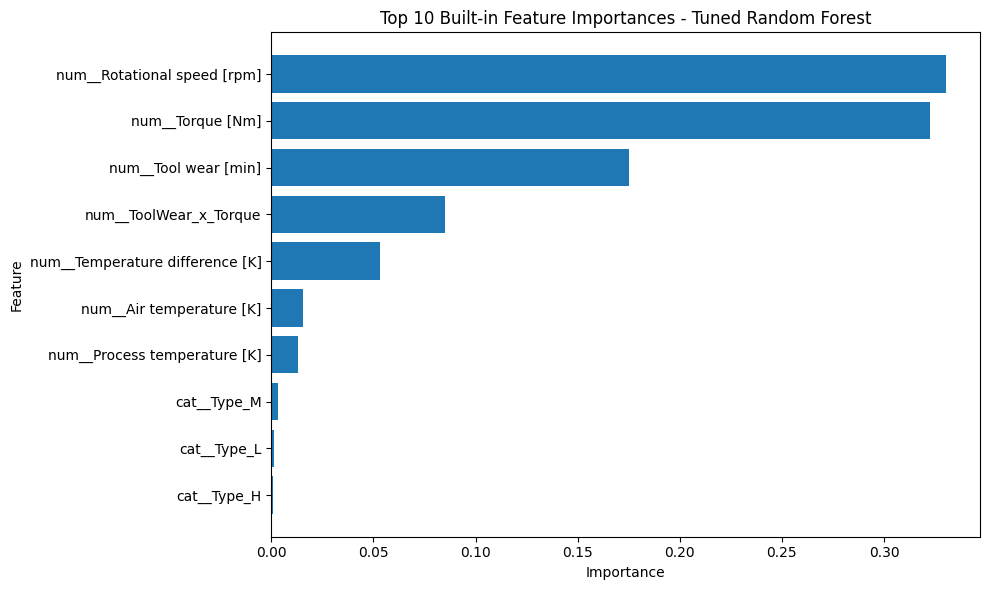

In [7]:
# Plot top 15 built-in feature importances
top_n = 10
top_features = feature_importance_df.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Built-in Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The built-in Random Forest feature importance shows that the final model relies most strongly on rotational speed, torque, and tool wear when predicting machine failure. These three variables clearly dominate the internal importance ranking, while the engineered interaction term Tool Wear x Torque and Temperature difference contribute more moderately, and the remaining variables have only limited influence.

At the same time, impurity-based feature importance should be interpreted with caution. Because some predictors are correlated, especially rotational speed and torque as well as air and process temperature, the importance values may be distributed unevenly across related variables. For that reason, this result should be treated as an initial global view and later compared with permutation importance and SHAP.

## 05. Permutation Importance

Permutation importance evaluates feature importance by measuring how much model performance decreases when the values of a feature are randomly shuffled.

Unlike built-in Random Forest importance, this method does not rely on internal split statistics. Instead, it tests how much each feature matters to actual predictive performance on unseen data. For that reason, permutation importance is often considered a stronger and more reliable global interpretability method.

Permutation importance is calculated on the test set so that the results reflect the behavior of the final model on out-of-sample data.

Average Precision is a suitable choice here because the target is imbalanced and this metric has already been used throughout the modeling workflow. The output shows how much predictive performance drops, on average, when each feature is disrupted. Features causing a larger drop are more important to the final model.

In [8]:
# Compute permutation importance on the test set
perm_importance = permutation_importance(
    rf_final,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
}).sort_values(by="Importance Mean", ascending=False)

perm_importance_df.head(15)

,Feature,Importance Mean,Importance Std
2,num__Rotational speed [rpm],0.599702,0.036749
5,num__Temperature difference [K],0.401252,0.047470
3,num__Torque [Nm],0.227325,0.012533
6,num__ToolWear_x_Torque,0.131522,0.010002
4,num__Tool wear [min],0.058453,0.007547
8,cat__Type_L,0.015202,0.007650
9,cat__Type_M,0.007844,0.004255
7,cat__Type_H,-0.000550,0.000434
0,num__Air temperature [K],-0.002513,0.005157
1,num__Process temperature [K],-0.006169,0.003638


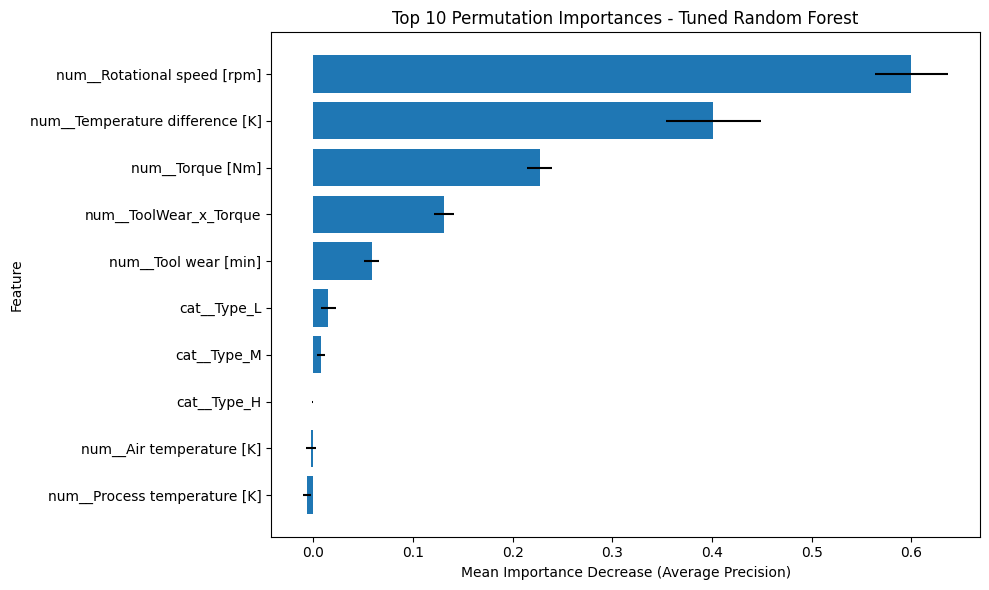

In [9]:
# Plot top 10 permutation importances
top_n = 10
top_perm = perm_importance_df.head(top_n).sort_values(by="Importance Mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_perm["Feature"], top_perm["Importance Mean"], xerr=top_perm["Importance Std"])
plt.title("Top 10 Permutation Importances - Tuned Random Forest")
plt.xlabel("Mean Importance Decrease (Average Precision)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The permutation importance analysis shows that rotational speed is the most influential feature in the final tuned Random Forest by a clear margin. Temperature difference, torque, the engineered ToolWear x Torque feature, and tool wear also make meaningful contributions, while the remaining variables add little predictive value once these stronger features are already available.

Compared with the built-in Random Forest importance, permutation importance gives a stronger role to Temperature difference and a weaker role to the original temperature variables. This suggests that the engineered temperature relationship captures the relevant signal more effectively than air temperature and process temperature considered separately.

The error bars represent the variability of the permutation importance across repeated random shuffles. Because permutation importance was calculated several times for each feature, the dispersion shows how stable the estimated performance decrease is. Features with large importance values and relatively small dispersion, such as rotational speed and torque, can be interpreted with higher confidence. Features with very small importance values and dispersion close to zero appear to have limited practical relevance for the final model.

## 06. Comparing Built-in Importance vs Permutation Importance

In [10]:
# Merge both importance measures for comparison
importance_comparison = feature_importance_df.merge(
    perm_importance_df[["Feature", "Importance Mean"]],
    on="Feature",
    how="inner"
).rename(columns={"Importance": "Built-in Importance",
                  "Importance Mean": "Permutation Importance"})

importance_comparison.sort_values(by="Permutation Importance", ascending=False).head(15)

,Feature,Built-in Importance,Permutation Importance
0,num__Rotational speed [rpm],0.330456,0.599702
4,num__Temperature difference [K],0.053166,0.401252
1,num__Torque [Nm],0.322340,0.227325
3,num__ToolWear_x_Torque,0.085125,0.131522
2,num__Tool wear [min],0.174998,0.058453
8,cat__Type_L,0.001348,0.015202
7,cat__Type_M,0.003190,0.007844
9,cat__Type_H,0.000740,-0.000550
5,num__Air temperature [K],0.015607,-0.002513
6,num__Process temperature [K],0.013028,-0.006169


The comparison between built-in Random Forest importance and permutation importance shows that the final model relies on a similar core set of features across both methods, but not with the same ranking. Rotational speed remains the most important feature in both views, which strengthens confidence that it is a key driver of the model’s predictions. Torque, ToolWear x Torque, tool wear, and Temperature difference also remain among the most relevant variables overall.

At the same time, the comparison highlights some important differences. Permutation importance assigns a much stronger role to Temperature difference than the built-in importance measure, while torque appears somewhat less dominant than in the tree-based ranking. This suggests that Temperature difference contributes more strongly to actual predictive performance on unseen data than the internal split-based importance alone would indicate. In contrast, air temperature and process temperature have very low or slightly negative permutation importance, which indicates that they add little independent predictive value once the engineered temperature relationship is already included.

Overall, this comparison suggests that the final model depends mainly on rotational speed, temperature difference, torque, and wear-related information. Because permutation importance reflects the effect of each feature on out-of-sample model performance, it should be treated as the more reliable global interpretation. The agreement between the two methods on the main features increases confidence in the interpretability results, while the differences help reveal which variables truly matter most for predictive quality.

## 07. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a more detailed interpretation of model predictions by estimating how each feature contributes to the output.

Compared with the previous methods, SHAP adds two important advantages:

- it helps explain not only global importance, but also the direction of feature effects
- it can explain individual predictions in addition to overall model behavior

In this notebook, SHAP is used as a deeper interpretability layer after the simpler global methods.

In [12]:
# Create SHAP explainer for the trained Random Forest
explainer = shap.TreeExplainer(rf_final)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

In [16]:
# For binary classification, use SHAP values for the positive class
shap_values_positive = shap_values[:, :, 1]

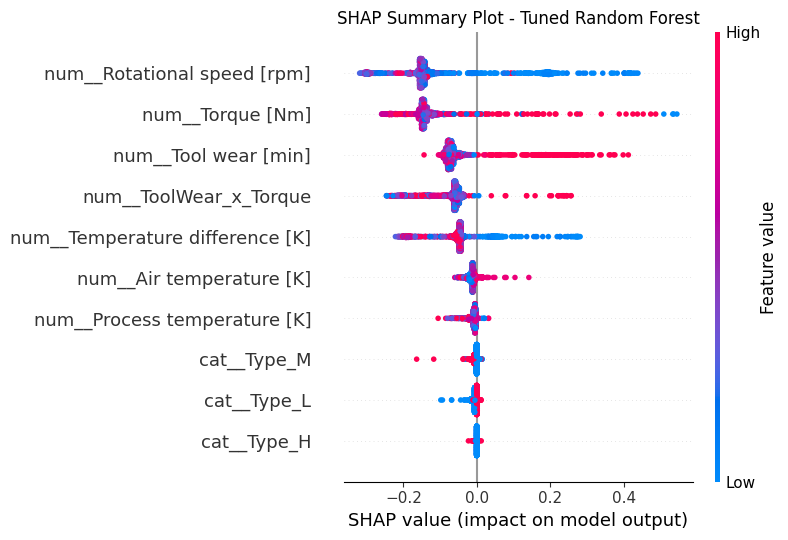

In [19]:

# SHAP summary plot
shap.summary_plot(shap_values_positive, X_test, show=False)
plt.title("SHAP Summary Plot - Tuned Random Forest")
plt.tight_layout()
plt.show()

In the SHAP summary plot, color indicates whether a feature value is high or low, while the horizontal position shows whether that value pushes the prediction toward or away from machine failure. Because the analysis uses SHAP values for the positive class, points on the right increase the model output for failure, while points on the left decrease it. For example, low rotational speed values (blue points) appear mainly on the positive side, which suggests that lower rotational speed tends to push predictions toward failure. In contrast, high torque and high tool wear values (red points) appear mainly on the positive side, indicating that they tend to increase predicted failure risk.

The SHAP summary plot shows that the tuned Random Forest is influenced mainly by rotational speed, torque, tool wear, ToolWear x Torque, and Temperature difference. Among these variables, lower rotational speed and higher torque and tool wear tend to push predictions more strongly toward machine failure. This pattern is broadly consistent with the earlier exploratory analysis and with the permutation importance results, which strengthens confidence that the final model is capturing meaningful failure-related behavior. In contrast, air temperature, process temperature, and product type contribute much less to the model output.

## 08. SHAP Local Explanation for One Failure Case

After the global SHAP summary, the next step is to inspect one individual example.

A local explanation is valuable because predictive maintenance decisions are often made at the level of specific machines or specific observations. Showing one case makes the notebook more concrete and demonstrates how the model’s prediction can be broken down into feature-level contributions.

In [21]:
# Identify one test instance that is an actual failure
failure_indices = y_test[y_test == 1].index

# Select the first available failure case
example_idx = failure_indices[0]

print("Selected example index:", example_idx)
print("Actual target value:", y_test.loc[example_idx])
print("Predicted probability of failure:", y_proba[example_idx])
print("Predicted class:", y_pred[example_idx])

Selected example index: 17
Actual target value: 1
Predicted probability of failure: 0.8935216569257233
Predicted class: 1


Using a real failure case makes the local explanation more meaningful, because it shows how the final model justified a positive prediction for an observation that truly belongs to the failure class.

In [22]:
# Display the feature values of the selected example
X_test.loc[[example_idx]]

,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temperature difference [K],num__ToolWear_x_Torque,cat__Type_H,cat__Type_L,cat__Type_M
17,1.85031,1.415455,-0.9745,1.177436,-0.278031,-1.600946,0.127417,0.0,1.0,0.0


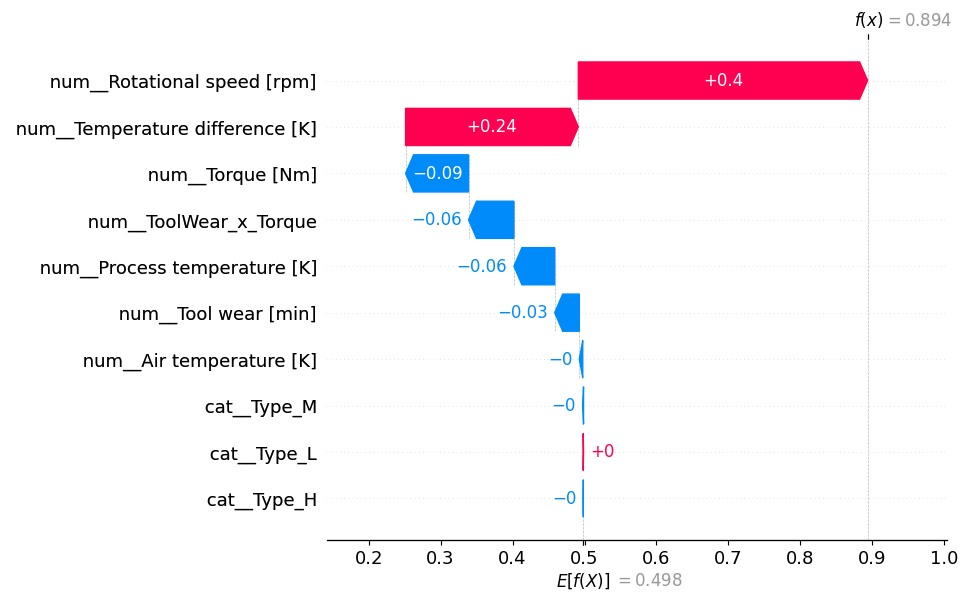

In [23]:
# Waterfall plot for one individual prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_values_positive[example_idx],
    feature_names=X_test.columns,
    features=X_test.loc[example_idx]
)
plt.show()

In [24]:
baseline = explainer.expected_value[1]
contrib_sum = shap_values_positive[example_idx].sum()
final_output = baseline + contrib_sum

print("Baseline:", baseline)
print("Sum of SHAP values:", contrib_sum)
print("Baseline + SHAP values:", final_output)

Baseline: 0.49835095730879164
Sum of SHAP values: 0.3951706996169482
Baseline + SHAP values: 0.8935216569257398


The SHAP waterfall plot shows that this individual prediction is driven mainly by rotational speed and Temperature difference, which push the model output strongly toward machine failure. Although several other features reduce the output slightly, their combined effect is not enough to offset the two strongest positive contributions. As a result, the final prediction for this case remains strongly in favor of failure.

## 09. Conclusions


The interpretability analysis shows that the tuned Random Forest is driven mainly by rotational speed, torque, tool wear, ToolWear x Torque, and Temperature difference. Across the different methods, rotational speed remains the most consistently important variable, while permutation importance and SHAP also highlight the strong contribution of Temperature difference and wear-related features. The results are consistent with the earlier exploratory analysis, which increases confidence that the final model is capturing meaningful operational patterns.

From a business perspective, this makes the final model more useful as a predictive maintenance tool. The model does not only provide strong predictive performance, but can also be explained in terms of machine-condition variables that are operationally plausible and relevant for monitoring. Overall, the tuned Random Forest remains a strong final model candidate because it combines good predictive performance with a level of interpretability that supports trust and communication with stakeholders.